# 13. Missing Data, Measurement Error, and Robust Inference

Analysts rarely get pristine data. Variables go missing, proxies stand in for latent constructs, and operational systems record noisy versions of the quantities that actually drive outcomes. We study how those imperfections distort inference and how more careful workflows can recover more defensible conclusions.


## Learning Objectives

After working through this lecture, you should be able to:

- distinguish MCAR, MAR, and MNAR missingness at a conceptual level,
- explain why naive complete-case or simple single-imputation workflows can distort inference,
- understand how classical measurement error attenuates relationships and can leak bias into other coefficients,
- implement a transparent multiple-imputation workflow and a simple regression-calibration workflow,
- translate robustness checks into both a decision recommendation and a technical diagnostic.


In [1]:
# Load the libraries and notebook settings used in the examples below.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import patsy
import statsmodels.api as sm
import statsmodels.formula.api as smf
from IPython.display import display

try:
    from notebooks._shared.display import smart_display
except Exception:
    def smart_display(value, **kwargs):
        """
        Display tables with notebook-friendly formatting.

        Parameters:
            value: Object to display, usually a pandas DataFrame.

        Returns:
            The IPython display result for `value`.

        Idea:
            Keep long table text readable in both live notebooks and rendered website pages.
        """
        return display(value)

# Use display settings that prevent text-heavy comparison tables from being truncated.
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", None)

sns.set_theme(style="whitegrid", context="notebook")

# Stable colors keep methods visually consistent across the notebook.
COLORS = {
    "oracle": "#0f172a",
    "complete_case": "#b45309",
    "mean_fill": "#7c3aed",
    "mi": "#2563eb",
    "mi_rc": "#15803d",
    "accent": "#dc2626",
    "soft": "#64748b",
}

rng = np.random.default_rng(20260614)


def logistic(x):
    """
    Convert a linear score into a probability.

    Parameters:
        x: Scalar or array of linear predictor values.

    Returns:
        Logistic probabilities on the interval from 0 to 1.

    Idea:
        Simulated treatment assignment and missingness need probabilities, not unrestricted linear scores.
    """
    return 1 / (1 + np.exp(-x))


def fit_outcome_model(df, usage_col="usage_proxy"):
    """
    Fit the renewal-margin outcome model used by each workflow.

    Parameters:
        df: Analysis DataFrame after a chosen missing-data or measurement-error workflow has been applied.
        usage_col: Name of the usage variable to include, either the raw proxy or calibrated usage estimate.

    Returns:
        A fitted OLS model for renewal margin in thousands of dollars.

    Idea:
        Holding the model formula fixed lets us isolate how data-quality choices change the priority-review estimate.
    """
    formula = (
        f"renewal_margin_k ~ priority_review + baseline_health + {usage_col} + "
        "contract_std + backlog_pressure + C(segment)"
    )
    return smf.ols(formula, data=df).fit()


def inference_from_model(model, method):
    """
    Extract parameter estimates and covariance from a fitted model.

    Parameters:
        model: Fitted statsmodels regression result.
        method: Label for the workflow that produced the fitted model.

    Returns:
        Dictionary containing the method label, coefficient vector, and covariance matrix.

    Idea:
        A common inference object keeps oracle, complete-case, imputed, and calibrated analyses comparable.
    """
    cov = model.cov_params()
    return {
        "method": method,
        "params": model.params.copy(),
        "cov": cov.copy(),
    }


def combine_inferences(inference_list, method):
    """
    Combine estimates from multiple imputed data sets using Rubin-style covariance logic.

    Parameters:
        inference_list: List of inference dictionaries, one for each imputed data set.
        method: Label for the combined workflow.

    Returns:
        Dictionary with pooled coefficient estimates and total covariance, including within- and between-imputation uncertainty.

    Idea:
        Multiple imputation should change both the point estimate and the uncertainty, not merely fill missing cells once.
    """
    params = pd.DataFrame([item["params"] for item in inference_list])
    param_order = params.columns
    q_bar = params.mean(axis=0)
    u_bar = sum(item["cov"].loc[param_order, param_order] for item in inference_list) / len(inference_list)
    centered = params - q_bar
    b_mat = centered.T.dot(centered) / (len(inference_list) - 1)
    total_cov = u_bar + (1 + 1 / len(inference_list)) * b_mat
    return {
        "method": method,
        "params": q_bar,
        "cov": total_cov,
    }


def summarize_parameter(inference, param, scale=1.0):
    """
    Summarize one coefficient estimate and its uncertainty.

    Parameters:
        inference: Dictionary with model coefficients and covariance for one workflow.
        param: Coefficient name to summarize.
        scale: Multiplicative scale factor for changing units.

    Returns:
        Dictionary with method label, point estimate, standard error, and approximate 95% interval.

    Idea:
        Decision tables need compact summaries of the same parameter across competing workflows.
    """
    estimate = float(inference["params"][param]) * scale
    se = float(np.sqrt(inference["cov"].loc[param, param])) * scale
    return {
        "method": inference["method"],
        "estimate": estimate,
        "se": se,
        "ci_low": estimate - 1.96 * se,
        "ci_high": estimate + 1.96 * se,
    }


def draw_bayes_linear_imputations(data, m=12, seed=123):
    """
    Draw multiple plausible baseline-health completions from a Bayesian linear imputation model.

    Parameters:
        data: Account-level DataFrame with observed and missing `baseline_health` values.
        m: Number of imputed data sets to generate.
        seed: Random seed for reproducible imputation draws.

    Returns:
        A list of completed DataFrames and the fitted linear imputation model for diagnostics.

    Idea:
        Missing values are uncertain predictions, so each completed data set should reflect both coefficient uncertainty and residual noise.
    """
    observed = data.loc[data["baseline_health"].notna()].copy()
    missing = data.loc[data["baseline_health"].isna()].copy()

    y_obs, X_obs = patsy.dmatrices(
        "baseline_health ~ usage_proxy + contract_std + backlog_pressure + priority_review + renewal_margin_k + C(segment)",
        observed,
        return_type="dataframe",
    )
    y_name = y_obs.columns[0]
    y_obs = y_obs[y_name]

    imputation_fit = sm.OLS(y_obs, X_obs).fit()
    design_info = X_obs.design_info
    x_miss = patsy.build_design_matrices([design_info], missing, return_type="dataframe")[0]

    beta_hat = imputation_fit.params.to_numpy()
    xtx_inv = np.linalg.inv(np.asarray(X_obs.T @ X_obs))
    sigma2_hat = float(imputation_fit.mse_resid)
    df_resid = int(imputation_fit.df_resid)

    local_rng = np.random.default_rng(seed)
    imputed_sets = []

    for draw_id in range(m):
        # Draw residual variance and coefficients before predicting missing health scores.
        sigma2_draw = df_resid * sigma2_hat / local_rng.chisquare(df_resid)
        beta_draw = local_rng.multivariate_normal(beta_hat, sigma2_draw * xtx_inv)
        imputed_values = x_miss.to_numpy() @ beta_draw + local_rng.normal(
            0, np.sqrt(sigma2_draw), size=len(missing)
        )

        completed = data.copy()
        completed.loc[completed["baseline_health"].isna(), "baseline_health"] = imputed_values
        completed["imputation_id"] = draw_id + 1
        imputed_sets.append(completed)

    return imputed_sets, imputation_fit


def add_regression_calibrated_usage(df):
    """
    Estimate latent usage from the audit subset and add calibrated usage to the full data set.

    Parameters:
        df: Completed account-level DataFrame with `usage_proxy` and audit-sample `usage_true_audit` values.

    Returns:
        A tuple with the calibrated DataFrame and the fitted audit-sample calibration model.

    Idea:
        The audit subset acts as a measurement bridge from noisy telemetry to the latent usage construct used in the outcome model.
    """
    audit = df.loc[df["usage_true_audit"].notna()].copy()
    calibration_fit = smf.ols(
        "usage_true_audit ~ usage_proxy + contract_std + backlog_pressure + priority_review + C(segment)",
        data=audit,
    ).fit()
    calibrated = df.copy()
    calibrated["usage_calibrated"] = calibration_fit.predict(df)
    return calibrated, calibration_fit


def method_summary_table(inference_list, param, label, units):
    """
    Build a method comparison table for one coefficient.

    Parameters:
        inference_list: Inference dictionaries to compare.
        param: Coefficient name to extract from each inference dictionary.
        label: Human-readable description of the coefficient.
        units: Unit label to display beside the estimate.

    Returns:
        DataFrame with method, estimate, standard error, and approximate 95% interval.

    Idea:
        Robustness analysis becomes easier to interpret when every workflow is summarized on the same target parameter.
    """
    rows = []
    for inf in inference_list:
        summary = summarize_parameter(inf, param)
        rows.append(
            {
                "method": inf["method"],
                f"{label} estimate ({units})": summary["estimate"],
                "SE": summary["se"],
                "95% CI lower": summary["ci_low"],
                "95% CI upper": summary["ci_high"],
            }
        )
    return pd.DataFrame(rows)


## 1. Why These Data Problems Matter

Missingness and measurement error attack inference in different ways.

If $R_i$ is an indicator that a value is observed, then:

- **MCAR** means $R_i$ is unrelated to the data values;
- **MAR** means missingness can depend on observed information but not on the missing value once observed information is conditioned on;
- **MNAR** means missingness still depends on the unobserved value itself, even after conditioning on observed information.

A standard expression of the MAR idea is

$$
\Pr(R_i = 1 \mid X_i^{\text{obs}}, X_i^{\text{mis}}, Y_i)
=
\Pr(R_i = 1 \mid X_i^{\text{obs}}, Y_i).
$$

Measurement error is different. If the analyst observes a noisy proxy $W_i$ for a latent covariate $X_i$, a common classical-error model is

$$
W_i = X_i + U_i, \qquad \mathbb{E}[U_i \mid X_i] = 0.
$$

In linear settings, this often attenuates the slope on the noisy predictor toward zero and can also distort nearby coefficients when the noisy predictor is correlated with treatment assignment or other regressors.

In practice, neither problem is solved by hand-waving. We need explicit workflows.


## 2. Case Study: Priority Reviews for At-Risk Accounts

A customer-success organization is evaluating a **priority review program** for enterprise and mid-market accounts that appear operationally fragile before renewal. The review program assigns extra analyst time to diagnose implementation problems and coordinate support escalation.

The decision question is:

> Should the firm expand the priority review program next quarter?

The key outcome is `renewal_margin_k`, the incremental renewal margin in thousands of dollars over the next quarter.

Two data-quality problems complicate the analysis:

1. `baseline_health`, a structured account-health score used as a control variable, is often missing when handoff documentation is incomplete.
2. `usage_proxy`, the operational telemetry score available to the analyst, is a noisy proxy for the latent product-usage intensity that actually affects outcomes.

### Variable Guide

| Variable | Role | Why it matters |
| --- | --- | --- |
| `priority_review` | Intervention indicator | Whether the account received the extra review workflow |
| `renewal_margin_k` | Continuous outcome | Margin impact used for the business decision |
| `baseline_health` | Confounder, partly missing | At-risk accounts both receive reviews and renew differently |
| `usage_proxy` | Noisy proxy | Available telemetry is not the latent construct we really want |
| `usage_true_audit` | Validation-sample measurement | Available only in a small audit subset |
| `contract_std` | Observed business context | Larger contracts behave differently and receive more attention |
| `backlog_pressure` | Operational pressure | Congested accounts are harder to stabilize |
| `segment` | Market segment | Enterprise, mid-market, and SMB contexts differ |


In [2]:
# Simulate an account portfolio with confounding, missing health scores, and noisy usage telemetry.
n_accounts = 2800

segments = np.array(["Enterprise", "Mid-market", "SMB"])
segment = rng.choice(segments, size=n_accounts, p=[0.27, 0.41, 0.32])

# Segment-level shifts create realistic business heterogeneity before treatment is assigned.
seg_contract = {"Enterprise": 0.9, "Mid-market": 0.2, "SMB": -0.55}
seg_health = {"Enterprise": 0.35, "Mid-market": 0.05, "SMB": -0.25}
seg_backlog = {"Enterprise": 0.10, "Mid-market": 0.00, "SMB": 0.30}
seg_treat = {"Enterprise": 0.30, "Mid-market": 0.05, "SMB": -0.20}
seg_outcome = {"Enterprise": 2.0, "Mid-market": 0.8, "SMB": -1.4}

contract_std = rng.normal([seg_contract[s] for s in segment], 0.85)
backlog_pressure = rng.normal([seg_backlog[s] for s in segment], 0.95) - 0.28 * contract_std

# Baseline health and latent usage are the real drivers; analysts will only observe health with missingness and usage with noise.
baseline_health_true = rng.normal(
    [seg_health[s] for s in segment], 0.75
) + 0.55 * contract_std - 0.65 * backlog_pressure

usage_true = rng.normal(
    0.75 * baseline_health_true + 0.35 * contract_std - 0.22 * backlog_pressure
    + np.array([0.22 if s == "Enterprise" else 0.04 if s == "Mid-market" else -0.18 for s in segment]),
    0.72,
)

# Treatment follows a targeted rule for large, pressured, lower-health accounts, with no random assignment.
treat_logit = (
    -0.45
    + 0.65 * contract_std
    - 0.95 * baseline_health_true
    + 0.35 * backlog_pressure
    + np.array([seg_treat[s] for s in segment])
)
priority_review = rng.binomial(1, logistic(treat_logit))

true_treatment_effect = 3.45
true_usage_effect = 2.60

renewal_margin_k = (
    18
    + true_treatment_effect * priority_review
    + 4.80 * baseline_health_true
    + true_usage_effect * usage_true
    + 1.70 * contract_std
    - 1.40 * backlog_pressure
    + np.array([seg_outcome[s] for s in segment])
    + rng.normal(0, 4.25, size=n_accounts)
)

# Telemetry is a noisy proxy for latent usage, which creates attenuation in naive outcome models.
usage_proxy = usage_true + rng.normal(0, 1.18, size=n_accounts)

margin_z = (renewal_margin_k - renewal_margin_k.mean()) / renewal_margin_k.std()
missing_logit = (
    -1.15
    + 0.75 * (segment == "SMB").astype(float)
    + 0.45 * backlog_pressure
    - 0.25 * priority_review
    - 0.40 * margin_z
)
health_missing = rng.binomial(1, logistic(missing_logit)).astype(bool)
baseline_health = baseline_health_true.copy()
baseline_health[health_missing] = np.nan

# The audit subset gives a high-quality usage measure for only a fraction of accounts.
audit_flag = rng.binomial(1, 0.14, size=n_accounts).astype(bool)
usage_true_audit = np.where(audit_flag, usage_true, np.nan)

analysis_df = pd.DataFrame(
    {
        "segment": segment,
        "contract_std": contract_std,
        "backlog_pressure": backlog_pressure,
        "priority_review": priority_review,
        "baseline_health": baseline_health,
        "baseline_health_true": baseline_health_true,
        "health_missing": health_missing,
        "usage_proxy": usage_proxy,
        "usage_true": usage_true,
        "usage_true_audit": usage_true_audit,
        "renewal_margin_k": renewal_margin_k,
        "audit_flag": audit_flag,
    }
)

portfolio_overview = pd.DataFrame(
    [
        {
            "quantity": "Accounts in analysis sample",
            "value": len(analysis_df),
        },
        {
            "quantity": "Share assigned to priority review",
            "value": analysis_df["priority_review"].mean(),
        },
        {
            "quantity": "Missing rate for baseline health",
            "value": analysis_df["health_missing"].mean(),
        },
        {
            "quantity": "Audit-sample share with true usage available",
            "value": analysis_df["audit_flag"].mean(),
        },
        {
            "quantity": "Hidden true treatment effect (simulation only)",
            "value": true_treatment_effect,
        },
        {
            "quantity": "Hidden true usage effect (simulation only)",
            "value": true_usage_effect,
        },
    ]
)

smart_display(portfolio_overview.round(3))


,quantity,value
0,Accounts in analysis sample,2800.000
1,Share assigned to priority review,0.419
2,Missing rate for baseline health,0.299
3,Audit-sample share with true usage available,0.150
4,Hidden true treatment effect (simulation only),3.450
5,Hidden true usage effect (simulation only),2.600


Because this is a teaching simulation, we know the latent truth. In real work, the analyst does **not** get the last two lines of the overview table. Those hidden truth values are included only so we can judge which workflow is closer to a defensible answer.

## 3. Diagnosing the Missingness Pattern

Before choosing a missing-data strategy, we should first ask a simpler question:

> Who is missing, and does the pattern look plausibly ignorable conditional on variables we observe?

We do not get to prove MAR from the data. But we can at least look for structure in the missingness process. If missingness is concentrated in particular business contexts, complete-case analysis will change the composition of the sample we are analyzing.


In [3]:
# Summarize missingness by segment and treatment status.
missingness_table = (
    analysis_df.groupby(["segment", "priority_review"], observed=False)
    .agg(
        accounts=("health_missing", "size"),
        missing_rate=("health_missing", "mean"),
        mean_margin=("renewal_margin_k", "mean"),
        mean_usage_proxy=("usage_proxy", "mean"),
        mean_backlog_pressure=("backlog_pressure", "mean"),
    )
    .reset_index()
)
missingness_table["priority_review"] = missingness_table["priority_review"].map({0: "No", 1: "Yes"})

# Compare full-sample and complete-case composition before fitting any outcome model.
complete_case_df = analysis_df.dropna(subset=["baseline_health"]).copy()
composition_table = pd.DataFrame(
    [
        {
            "sample": "All accounts",
            "n": len(analysis_df),
            "priority_review_rate": analysis_df["priority_review"].mean(),
            "mean_contract_std": analysis_df["contract_std"].mean(),
            "mean_backlog_pressure": analysis_df["backlog_pressure"].mean(),
            "mean_usage_proxy": analysis_df["usage_proxy"].mean(),
            "mean_renewal_margin_k": analysis_df["renewal_margin_k"].mean(),
        },
        {
            "sample": "Complete cases only",
            "n": len(complete_case_df),
            "priority_review_rate": complete_case_df["priority_review"].mean(),
            "mean_contract_std": complete_case_df["contract_std"].mean(),
            "mean_backlog_pressure": complete_case_df["backlog_pressure"].mean(),
            "mean_usage_proxy": complete_case_df["usage_proxy"].mean(),
            "mean_renewal_margin_k": complete_case_df["renewal_margin_k"].mean(),
        },
    ]
)

smart_display(missingness_table.round(3))
smart_display(composition_table.round(3))


,segment,priority_review,accounts,missing_rate,mean_margin,mean_usage_proxy,mean_backlog_pressure
0,Enterprise,No,492,0.171,33.199,1.608,-0.441
1,Enterprise,Yes,284,0.190,27.782,0.802,0.266
2,Mid-market,No,656,0.206,25.196,0.676,-0.393
3,Mid-market,Yes,461,0.217,20.674,-0.085,0.261
4,SMB,No,479,0.503,11.878,-0.799,0.120
5,SMB,Yes,428,0.523,7.450,-1.700,0.813


,sample,n,priority_review_rate,mean_contract_std,mean_backlog_pressure,mean_usage_proxy,mean_renewal_margin_k
0,All accounts,2800,0.419,0.163,0.045,0.112,21.129
1,Complete cases only,1962,0.405,0.332,-0.143,0.470,24.340


The missingness table shows that baseline-health documentation is not missing at random in a casual, harmless sense. SMB accounts lose health records at roughly half the sample, while enterprise and mid-market accounts have much lower missing rates. The complete-case sample also has higher average contract size, lower backlog pressure, and higher renewal margin than the full portfolio. Dropping missing rows therefore changes who the analysis represents.

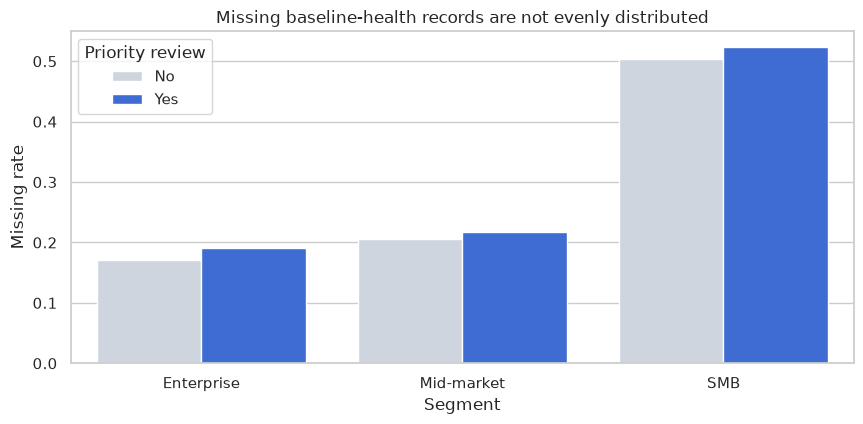

In [4]:
# Plot missingness rates to make compositional imbalance visible.
plot_df = missingness_table.copy()

fig, ax = plt.subplots(figsize=(8.8, 4.4))
sns.barplot(
    data=plot_df,
    x="segment",
    y="missing_rate",
    hue="priority_review",
    palette=["#cbd5e1", "#2563eb"],
    ax=ax,
)
ax.set_title("Missing baseline-health records are not evenly distributed")
ax.set_xlabel("Segment")
ax.set_ylabel("Missing rate")
ax.legend(title="Priority review")
plt.tight_layout()
plt.show()


Two things matter here.

First, the probability of a missing health score is not flat across the portfolio. Second, the complete-case sample is smaller and compositionally different. That means complete-case analysis changes both precision and the business population being analyzed.

## 4. Naive Workflows: Complete Cases and Segment-Mean Fill

We start with two common but imperfect approaches:

1. **Complete-case analysis:** drop accounts with missing health scores.
2. **Segment-mean fill:** replace missing health values with the average within each segment.

The second approach often feels practical because it preserves sample size. But deterministic single imputation treats guessed values as if they were known exactly, which typically understates uncertainty.


In [5]:
# Fit oracle and naive workflows against the same renewal-margin target.
oracle_model = smf.ols(
    "renewal_margin_k ~ priority_review + baseline_health_true + usage_true + contract_std + backlog_pressure + C(segment)",
    data=analysis_df,
).fit()
oracle_inf = inference_from_model(oracle_model, "Oracle: latent truth")

complete_case_model = fit_outcome_model(complete_case_df, usage_col="usage_proxy")
complete_case_inf = inference_from_model(complete_case_model, "Complete cases")

# Segment-mean fill preserves row count but removes within-segment imputation uncertainty.
mean_fill_df = analysis_df.copy()
mean_fill_df["baseline_health"] = mean_fill_df["baseline_health"].fillna(
    mean_fill_df.groupby("segment")["baseline_health"].transform("mean")
)
mean_fill_model = fit_outcome_model(mean_fill_df, usage_col="usage_proxy")
mean_fill_inf = inference_from_model(mean_fill_model, "Segment-mean fill")

naive_treatment_table = method_summary_table(
    [oracle_inf, complete_case_inf, mean_fill_inf],
    param="priority_review",
    label="Priority-review effect",
    units="$k",
)
smart_display(naive_treatment_table.round(3))


,method,Priority-review effect estimate ($k),SE,95% CI lower,95% CI upper
0,Oracle: latent truth,3.494,0.182,3.136,3.852
1,Complete cases,3.251,0.239,2.783,3.720
2,Segment-mean fill,1.754,0.236,1.292,2.216


The naive workflows fail in different ways. Complete-case analysis keeps the priority-review coefficient closer to the oracle than segment-mean fill, but it does so after discarding a systematically different subset of accounts. Segment-mean fill is worse for the treatment effect because it smooths away meaningful health variation and treats imputed values as known. On the usage side, both naive workflows are badly attenuated because the observed usage proxy is noisy.

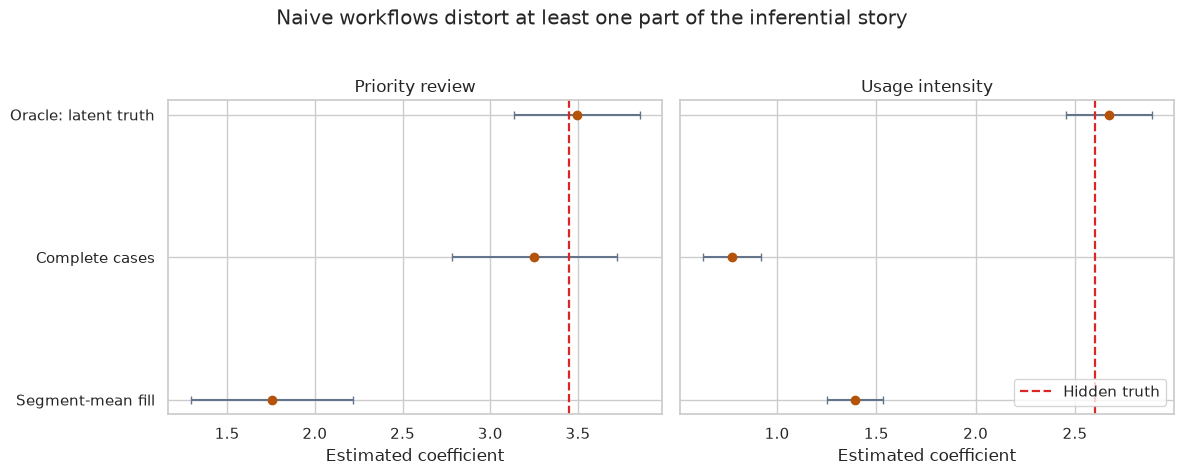

In [6]:
# Build coefficient-interval rows for treatment and usage estimates under naive workflows.
naive_plot_rows = []
for inf in [oracle_inf, complete_case_inf, mean_fill_inf]:
    if inf["method"] == "Oracle: latent truth":
        tr = summarize_parameter(inf, "priority_review")
        us = summarize_parameter(inf, "usage_true")
    else:
        tr = summarize_parameter(inf, "priority_review")
        us = summarize_parameter(inf, "usage_proxy")
    naive_plot_rows.extend(
        [
            {"method": inf["method"], "parameter": "Priority review", **tr},
            {"method": inf["method"], "parameter": "Usage intensity", **us},
        ]
    )

naive_plot_df = pd.DataFrame(naive_plot_rows)
method_order = ["Oracle: latent truth", "Complete cases", "Segment-mean fill"]

# Plot both the treatment effect and the usage coefficient against their hidden simulation truths.
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6), sharey=True)
for ax, parameter, true_value in zip(
    axes,
    ["Priority review", "Usage intensity"],
    [true_treatment_effect, true_usage_effect],
):
    subset = naive_plot_df.loc[naive_plot_df["parameter"] == parameter].copy()
    subset["method"] = pd.Categorical(subset["method"], categories=method_order, ordered=True)
    subset = subset.sort_values("method", ascending=False)

    ax.errorbar(
        subset["estimate"],
        subset["method"],
        xerr=1.96 * subset["se"],
        fmt="o",
        color=COLORS["complete_case"],
        ecolor=COLORS["soft"],
        capsize=3,
    )
    ax.axvline(true_value, color=COLORS["accent"], linestyle="--", linewidth=1.6, label="Hidden truth")
    ax.set_title(parameter)
    ax.set_xlabel("Estimated coefficient")

axes[0].set_ylabel("")
axes[1].legend(frameon=True, loc="lower right")
fig.suptitle("Naive workflows distort at least one part of the inferential story", y=1.03)
plt.tight_layout()
plt.show()


The complete-case workflow pays a double price: it discards information and changes the sample composition. Segment-mean fill preserves the row count, but it treats unknown health scores as if they were observed with certainty. Neither workflow is a satisfying answer once the decision is consequential.

## 5. Multiple Imputation Under a MAR Working Model

A more principled response is to impute the missing health scores several times, fit the analysis model to each completed data set, and then combine the estimates.

The large-sample Rubin combination rules can be written as

$$
\bar Q = \frac{1}{m} \sum_{j=1}^{m} Q_j,
\qquad
T = \bar U + \left(1 + \frac{1}{m}\right) B,
$$

where:

- $Q_j$ is the parameter estimate from imputed data set $j$,
- $\bar U$ is the average within-imputation covariance,
- $B$ is the between-imputation covariance.

For transparency, we use a simple Bayesian linear-regression imputation model for `baseline_health` that conditions on observed business context, treatment assignment, the noisy usage proxy, and the observed outcome. This is one valid and easy-to-inspect MI workflow.


In [7]:
# Draw multiple completed datasets and combine treatment-effect estimates across them.
imputed_sets, imputation_fit = draw_bayes_linear_imputations(analysis_df, m=14, seed=202)

mi_inferences = []
for completed in imputed_sets:
    mi_model = fit_outcome_model(completed, usage_col="usage_proxy")
    mi_inferences.append(inference_from_model(mi_model, "MI under MAR"))

mi_inf = combine_inferences(mi_inferences, "Multiple imputation")

mi_treatment_table = method_summary_table(
    [oracle_inf, complete_case_inf, mean_fill_inf, mi_inf],
    param="priority_review",
    label="Priority-review effect",
    units="$k",
)
smart_display(mi_treatment_table.round(3))

# Diagnostic summaries describe the imputation model, not proof that MAR is true.
imputation_diagnostics = pd.DataFrame(
    [
        {
            "quantity": "Observed mean baseline health",
            "value": analysis_df.loc[analysis_df["baseline_health"].notna(), "baseline_health"].mean(),
        },
        {
            "quantity": "Observed SD baseline health",
            "value": analysis_df.loc[analysis_df["baseline_health"].notna(), "baseline_health"].std(),
        },
        {
            "quantity": "Posterior-imputation R-squared",
            "value": imputation_fit.rsquared,
        },
        {
            "quantity": "Number of imputations",
            "value": len(imputed_sets),
        },
    ]
)

smart_display(imputation_diagnostics.round(3))


,method,Priority-review effect estimate ($k),SE,95% CI lower,95% CI upper
0,Oracle: latent truth,3.494,0.182,3.136,3.852
1,Complete cases,3.251,0.239,2.783,3.720
2,Segment-mean fill,1.754,0.236,1.292,2.216
3,Multiple imputation,3.374,0.209,2.965,3.783


,quantity,value
0,Observed mean baseline health,0.394
1,Observed SD baseline health,1.300
2,Posterior-imputation R-squared,0.857
3,Number of imputations,14.000


Multiple imputation does not magically identify the missing values. What it does is propagate uncertainty in a way that deterministic fill methods do not. When the MAR working model is reasonable, MI often recovers both a better center and a more honest interval.

## 6. Measurement Error and a Reliability-Subset Calibration Workflow

Multiple imputation helps with missing health scores, but it does not fix the noisy usage proxy.

We therefore use the validation subset `usage_true_audit`, where a smaller telemetry audit recovers a higher-quality usage measure. A simple regression-calibration workflow predicts latent usage from the observed proxy and other business context, then plugs that calibrated estimate into the outcome model.

We use a transparent approximation to a full latent-variable model. That is intentional: the aim is to show the logic of correction before moving to more advanced machinery.


In [8]:
# Calibrate noisy usage in each imputed dataset using the audit subset.
calibration_rows = []
calibrated_inferences = []
calibration_slopes = []

for completed in imputed_sets:
    calibrated_df, calibration_fit = add_regression_calibrated_usage(completed)
    calibrated_model = fit_outcome_model(calibrated_df, usage_col="usage_calibrated")
    calibrated_inferences.append(inference_from_model(calibrated_model, "MI + regression calibration"))
    calibration_slopes.append(calibration_fit.params["usage_proxy"])

mi_rc_inf = combine_inferences(calibrated_inferences, "MI + regression calibration")

# Refit one calibration model for display and scatterplot diagnostics.
reliability_subset = imputed_sets[0].loc[imputed_sets[0]["audit_flag"]].copy()
reliability_fit = smf.ols(
    "usage_true_audit ~ usage_proxy + contract_std + backlog_pressure + priority_review + C(segment)",
    data=reliability_subset,
).fit()
reliability_subset["usage_fitted"] = reliability_fit.predict(reliability_subset)

calibration_table = pd.DataFrame(
    [
        {
            "quantity": "Audit sample size",
            "value": len(reliability_subset),
        },
        {
            "quantity": "Correlation(true usage, proxy) in audit sample",
            "value": reliability_subset[["usage_true_audit", "usage_proxy"]].corr().iloc[0, 1],
        },
        {
            "quantity": "Average slope on usage proxy in calibration model",
            "value": np.mean(calibration_slopes),
        },
        {
            "quantity": "Oracle usage coefficient",
            "value": true_usage_effect,
        },
    ]
)

smart_display(calibration_table.round(3))


,quantity,value
0,Audit sample size,420.000
1,"Correlation(true usage, proxy) in audit sample",0.820
2,Average slope on usage proxy in calibration model,0.357
3,Oracle usage coefficient,2.600


The audit sample confirms that the usage proxy is informative but far from a clean measure of latent usage. The correlation is high enough to justify calibration, yet the calibration slope is much smaller than one, which is exactly what the scatterplot later shows. A one-unit movement in the proxy does not translate into a one-unit movement in audited usage.

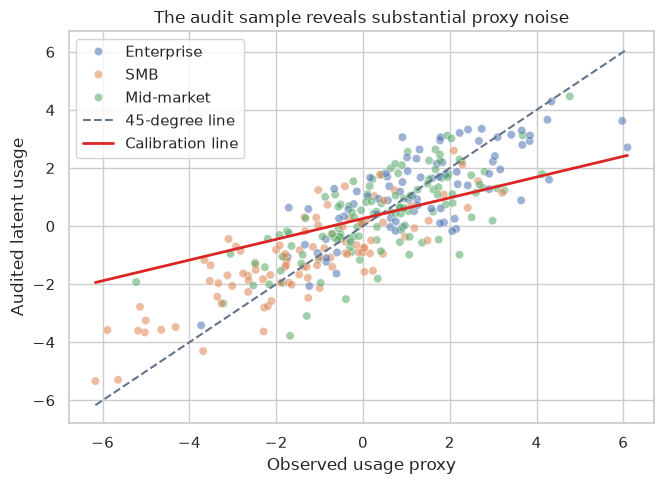

In [9]:
# Compare audited latent usage with the noisy proxy in the reliability subset.
fig, ax = plt.subplots(figsize=(6.8, 5.0))
sns.scatterplot(
    data=reliability_subset.sample(min(300, len(reliability_subset)), random_state=7),
    x="usage_proxy",
    y="usage_true_audit",
    hue="segment",
    alpha=0.55,
    palette="deep",
    ax=ax,
)
# Hold other covariates fixed to show a clean calibration line as proxy usage changes.
x_grid = np.linspace(reliability_subset["usage_proxy"].min(), reliability_subset["usage_proxy"].max(), 120)
mean_contract = reliability_subset["contract_std"].mean()
mean_backlog = reliability_subset["backlog_pressure"].mean()
ref_segment = "Mid-market"
calib_line = reliability_fit.predict(
    pd.DataFrame(
        {
            "usage_proxy": x_grid,
            "contract_std": mean_contract,
            "backlog_pressure": mean_backlog,
            "priority_review": 0,
            "segment": ref_segment,
        }
    )
)

ax.plot(x_grid, x_grid, linestyle="--", linewidth=1.5, color=COLORS["soft"], label="45-degree line")
ax.plot(x_grid, calib_line, linewidth=2.0, color=COLORS["accent"], label="Calibration line")
ax.set_title("The audit sample reveals substantial proxy noise")
ax.set_xlabel("Observed usage proxy")
ax.set_ylabel("Audited latent usage")
ax.legend(frameon=True, loc="upper left")
plt.tight_layout()
plt.show()


The audit plot is the whole reason a reliability subset matters. Without a better measurement on at least some units, we would know the proxy is imperfect only in theory. With the audit subset, we can actually estimate how the proxy maps back to the latent construct we care about.

## 7. Putting the Workflows Side by Side

We now compare five inferential positions:

1. **Oracle:** uses latent truth, available only because this is a simulation.
2. **Complete cases**
3. **Segment-mean fill**
4. **Multiple imputation**
5. **Multiple imputation plus regression calibration**

The comparison is especially interesting because different methods can look similar on the treatment effect while telling very different stories about the covariate structure, or vice versa.


In [10]:
# Summarize treatment and usage coefficients across all workflows.
comparison_inferences = [oracle_inf, complete_case_inf, mean_fill_inf, mi_inf, mi_rc_inf]

treatment_table = method_summary_table(
    comparison_inferences,
    param="priority_review",
    label="Priority-review effect",
    units="$k",
)

# The usage parameter name changes after regression calibration, so map it explicitly.
usage_rows = []
for inf in comparison_inferences:
    usage_param = "usage_true" if inf["method"] == "Oracle: latent truth" else (
        "usage_calibrated" if inf["method"] == "MI + regression calibration" else "usage_proxy"
    )
    usage_rows.append(summarize_parameter(inf, usage_param))
    usage_rows[-1]["method"] = inf["method"]
usage_table = pd.DataFrame(usage_rows).rename(
    columns={
        "estimate": "Usage coefficient estimate ($k per unit)",
        "se": "SE",
        "ci_low": "95% CI lower",
        "ci_high": "95% CI upper",
    }
)

smart_display(treatment_table.round(3))
smart_display(usage_table.round(3))


,method,Priority-review effect estimate ($k),SE,95% CI lower,95% CI upper
0,Oracle: latent truth,3.494,0.182,3.136,3.852
1,Complete cases,3.251,0.239,2.783,3.720
2,Segment-mean fill,1.754,0.236,1.292,2.216
3,Multiple imputation,3.374,0.209,2.965,3.783
4,MI + regression calibration,4.045,0.220,3.614,4.476


,method,Usage coefficient estimate ($k per unit),SE,95% CI lower,95% CI upper
0,Oracle: latent truth,2.671,0.110,2.456,2.886
1,Complete cases,0.772,0.075,0.625,0.919
2,Segment-mean fill,1.392,0.073,1.249,1.535
3,Multiple imputation,0.746,0.073,0.604,0.889
4,MI + regression calibration,2.090,0.204,1.691,2.490


The side-by-side tables show why missingness and measurement error should be diagnosed separately. Multiple imputation repairs much of the treatment-effect distortion caused by missing health scores, but the usage coefficient remains severely attenuated because the proxy is still noisy. Adding regression calibration moves the usage coefficient much closer to the oracle, although it also changes the treatment-effect estimate because calibrated usage is correlated with review assignment and account context.

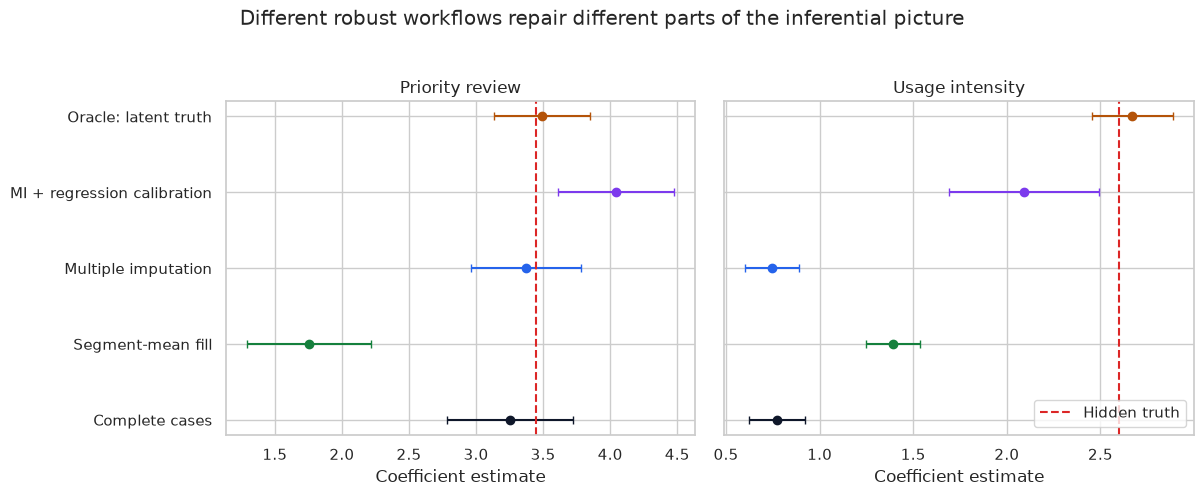

In [11]:
# Build interval-plot rows for the treatment and usage coefficients across all workflows.
comparison_rows = []
for inf in comparison_inferences:
    treatment_summary = summarize_parameter(inf, "priority_review")
    usage_param = "usage_true" if inf["method"] == "Oracle: latent truth" else (
        "usage_calibrated" if inf["method"] == "MI + regression calibration" else "usage_proxy"
    )
    usage_summary = summarize_parameter(inf, usage_param)
    comparison_rows.extend(
        [
            {"method": inf["method"], "parameter": "Priority review", **treatment_summary},
            {"method": inf["method"], "parameter": "Usage intensity", **usage_summary},
        ]
    )

comparison_plot_df = pd.DataFrame(comparison_rows)
ordered_methods = [
    "Oracle: latent truth",
    "MI + regression calibration",
    "Multiple imputation",
    "Segment-mean fill",
    "Complete cases",
]

# The vertical line in each panel is the hidden simulation truth for that coefficient.
fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.8), sharey=True)
for ax, parameter, truth in zip(
    axes,
    ["Priority review", "Usage intensity"],
    [true_treatment_effect, true_usage_effect],
):
    subset = comparison_plot_df.loc[comparison_plot_df["parameter"] == parameter].copy()
    subset["method"] = pd.Categorical(subset["method"], categories=ordered_methods, ordered=True)
    subset = subset.sort_values("method", ascending=False)

    palette = [
        COLORS["oracle"],
        COLORS["mi_rc"],
        COLORS["mi"],
        COLORS["mean_fill"],
        COLORS["complete_case"],
    ]

    for color, (_, row) in zip(palette, subset.iterrows()):
        ax.errorbar(
            row["estimate"],
            row["method"],
            xerr=1.96 * row["se"],
            fmt="o",
            color=color,
            ecolor=color,
            capsize=3,
        )

    ax.axvline(truth, color=COLORS["accent"], linestyle="--", linewidth=1.5, label="Hidden truth")
    ax.set_title(parameter)
    ax.set_xlabel("Coefficient estimate")

axes[1].legend(frameon=True, loc="lower right")
fig.suptitle("Different robust workflows repair different parts of the inferential picture", y=1.03)
plt.tight_layout()
plt.show()


There are two separate wins to look for here:

- a treatment-effect estimate that better reflects the real intervention contrast, and
- a covariate coefficient structure that better reflects the role of the underlying business drivers.

A method can improve one dimension more than the other. In this simulation, multiple imputation comes closest on the treatment effect, while multiple imputation plus regression calibration does much more to repair the attenuated usage coefficient. That is part of why robustness work is not reducible to a single checkbox.

## 8. Decision Consequence: Expand, Hold, or Rework the Program?

Suppose next quarter the firm expects to place **900 accounts** into the eligibility pool for priority review. The review workflow costs about **USD 3.0k per account** in analyst time and coordination overhead.

A simple decision metric is therefore:

$$
\text{Expected net value} = N_{\text{eligible}} \times (\widehat{\tau} - 3.0),
$$

where $\widehat{\tau}$ is the estimated per-account renewal-margin lift in thousands of dollars.

This simple utility proxy is enough to show how the inferential workflow can change the business recommendation.


In [12]:
# Translate treatment-effect estimates into an expansion decision under a simple cost rule.
eligible_accounts_next_quarter = 900
cost_per_account_k = 3.0

# The action rule uses both point estimates and whether the lower interval clears cost.
decision_rows = []
for inf in comparison_inferences:
    treat = summarize_parameter(inf, "priority_review")
    net_value_k = eligible_accounts_next_quarter * (treat["estimate"] - cost_per_account_k)
    if treat["estimate"] > cost_per_account_k and treat["ci_low"] > cost_per_account_k:
        action = "Expand with monitoring"
    elif treat["estimate"] > cost_per_account_k:
        action = "Continue as a targeted pilot"
    else:
        action = "Do not expand yet"

    decision_rows.append(
        {
            "method": inf["method"],
            "effect_estimate_k": treat["estimate"],
            "95% CI lower": treat["ci_low"],
            "95% CI upper": treat["ci_high"],
            "expected_net_value_k": net_value_k,
            "action": action,
        }
    )

decision_table = pd.DataFrame(decision_rows)
smart_display(decision_table.round(3))


,method,effect_estimate_k,95% CI lower,95% CI upper,expected_net_value_k,action
0,Oracle: latent truth,3.494,3.136,3.852,444.461,Expand with monitoring
1,Complete cases,3.251,2.783,3.720,226.323,Continue as a targeted pilot
2,Segment-mean fill,1.754,1.292,2.216,-1121.530,Do not expand yet
3,Multiple imputation,3.374,2.965,3.783,336.414,Continue as a targeted pilot
4,MI + regression calibration,4.045,3.614,4.476,940.385,Expand with monitoring


The decision table turns the statistical differences into business consequences. Segment-mean fill would recommend not expanding because it badly understates the treatment effect. Complete cases and MI both support continuing as a targeted pilot, while the calibrated workflow supports expansion with monitoring. These are not small cosmetic differences; they are different recommendations for the same portfolio.

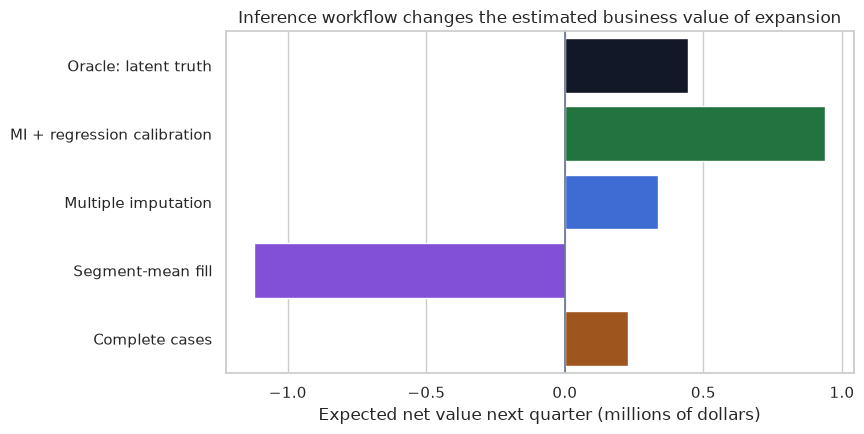

In [13]:
# Plot how each workflow changes the expected value calculation.
decision_plot = decision_table.copy()
decision_plot["expected_net_value_m"] = decision_plot["expected_net_value_k"] / 1000
decision_plot["method"] = pd.Categorical(
    decision_plot["method"],
    categories=ordered_methods,
    ordered=True,
)
decision_plot = decision_plot.sort_values("method")

fig, ax = plt.subplots(figsize=(8.8, 4.5))
# Match bar colors to the workflow colors used in earlier coefficient plots.
palette = [
    COLORS["oracle"],
    COLORS["mi_rc"],
    COLORS["mi"],
    COLORS["mean_fill"],
    COLORS["complete_case"],
]
# Horizontal bars make positive and negative net value easy to compare.
sns.barplot(
    data=decision_plot,
    x="expected_net_value_m",
    y="method",
    hue="method",
    palette=palette,
    dodge=False,
    legend=False,
    ax=ax,
)
ax.axvline(0, color=COLORS["soft"], linewidth=1.2)
ax.set_title("Inference workflow changes the estimated business value of expansion")
ax.set_xlabel("Expected net value next quarter (millions of dollars)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


This is why the example matters. Missingness and measurement error are technical nuisances with enough practical force to flip the operational recommendation. The more expensive or higher-stakes the intervention, the less acceptable it becomes to shrug off those data defects.

## 9. Sensitivity Analysis for Worse-Than-MAR Missing Cases

Multiple imputation rests on a MAR working model. But analysts should still ask:

> What if the accounts with missing health scores were systematically worse than the imputation model predicts?

We probe that question with a simple delta adjustment. For each imputed data set, we shift the imputed health scores downward for originally missing cases and recompute the MI + regression-calibration estimate.

This is not a proof against MNAR. It is a disciplined way to quantify how fragile the recommendation is to one plausible departure from the working assumptions.


In [14]:
# Apply increasingly pessimistic shifts to imputed health scores for originally missing cases.
sensitivity_deltas = [0.0, -0.2, -0.4, -0.6, -0.8]
sensitivity_rows = []

# Refit the full MI + regression-calibration workflow under each shifted scenario.
for delta in sensitivity_deltas:
    shifted_inferences = []
    for completed in imputed_sets:
        shifted = completed.copy()
        shifted.loc[shifted["health_missing"], "baseline_health"] = (
            shifted.loc[shifted["health_missing"], "baseline_health"] + delta
        )
        shifted_calibrated, _ = add_regression_calibrated_usage(shifted)
        shifted_model = fit_outcome_model(shifted_calibrated, usage_col="usage_calibrated")
        shifted_inferences.append(inference_from_model(shifted_model, f"delta={delta:.1f}"))

    combined_shift = combine_inferences(shifted_inferences, f"delta={delta:.1f}")
    treat = summarize_parameter(combined_shift, "priority_review")
    sensitivity_rows.append(
        {
            "delta_shift": delta,
            "effect_estimate_k": treat["estimate"],
            "ci_low": treat["ci_low"],
            "ci_high": treat["ci_high"],
            "expected_net_value_m": eligible_accounts_next_quarter * (treat["estimate"] - cost_per_account_k) / 1000,
        }
    )

sensitivity_table = pd.DataFrame(sensitivity_rows)
smart_display(sensitivity_table.round(3))


,delta_shift,effect_estimate_k,ci_low,ci_high,expected_net_value_m
0,0.0,4.045,3.614,4.476,0.940
1,-0.2,3.938,3.508,4.367,0.844
2,-0.4,3.783,3.352,4.213,0.704
3,-0.6,3.600,3.166,4.034,0.540
4,-0.8,3.409,2.970,3.848,0.368


The sensitivity table says the recommendation is not fragile to the delta shifts tested here. Even when missing health scores are shifted downward by 0.8 standard-score units, the estimated effect remains above the break-even cost and expected net value stays positive. The robustness claim is concrete, while the MAR assumption still needs domain scrutiny.

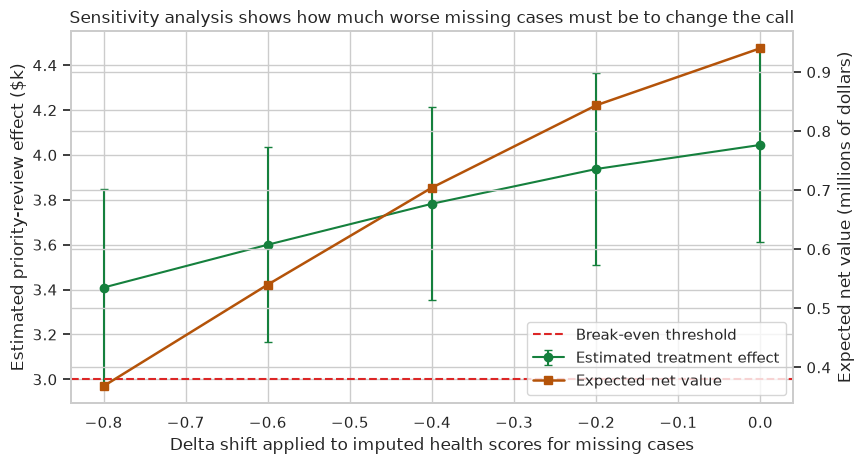

In [15]:
# Track both the coefficient and expected value as the MNAR-style delta shift changes.
fig, ax1 = plt.subplots(figsize=(8.8, 4.8))
ax1.errorbar(
    sensitivity_table["delta_shift"],
    sensitivity_table["effect_estimate_k"],
    yerr=(sensitivity_table["effect_estimate_k"] - sensitivity_table["ci_low"]),
    fmt="o-",
    color=COLORS["mi_rc"],
    capsize=3,
    label="Estimated treatment effect",
)
ax1.axhline(cost_per_account_k, color=COLORS["accent"], linestyle="--", linewidth=1.5, label="Break-even threshold")
ax1.set_xlabel("Delta shift applied to imputed health scores for missing cases")
ax1.set_ylabel("Estimated priority-review effect ($k)")

# A second axis keeps dollars visually separate from the coefficient scale.
ax2 = ax1.twinx()
ax2.plot(
    sensitivity_table["delta_shift"],
    sensitivity_table["expected_net_value_m"],
    marker="s",
    color=COLORS["complete_case"],
    linewidth=1.8,
    label="Expected net value",
)
ax2.set_ylabel("Expected net value (millions of dollars)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=True, loc="lower right")
ax1.set_title("Sensitivity analysis shows how much worse missing cases must be to change the call")
plt.tight_layout()
plt.show()


A sensitivity analysis like this does not certify the model. What it does is replace vague anxiety with a concrete robustness statement. That is usually a better conversation with stakeholders than pretending the MAR assumption was somehow verified.

<!-- real-data-companion-course01 -->
## Real-Data Companion: Missingness Stress Test on RAND HIE

RAND HIE does not arrive as a messy missing-data example, so this companion uses a transparent stress test. We start from real utilization data, then artificially mask self-rated health more often among high-utilization records. This creates a known missingness mechanism on top of real outcomes and covariates.

The unit is a person-period record. The outcome is outpatient physician visits, while the stressed covariate is a health-status measure. Because the masking rule is related to utilization, complete-case analysis and simple imputation can move the estimated relationship in ways that would be easy to miss if the missingness mechanism were ignored.

The masking exercise is a teaching device. The diagnostic habit is the important part: when missingness is plausibly related to outcomes, analysts should compare complete-case, imputed, and sensitivity scenarios before presenting a single clean estimate.

Data source: [RAND Health Insurance Experiment in statsmodels](https://www.statsmodels.org/stable/datasets/generated/randhie.html).

In [16]:
# real-data-companion-course01
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf


def _find_project_root(start=Path.cwd()):
    """
    Find the nearest project root that exposes shared notebook helpers.

    Parameters:
        start: Directory from which the upward search begins, usually the current notebook working directory.

    Returns:
        The closest parent path containing `notebooks/_shared`; returns `start` when the helper directory is unavailable.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.display import smart_display
from notebooks._shared.real_data import load_statsmodels_randhie, optional_data_note

RUN_REAL_DATA_COMPANION = True

if RUN_REAL_DATA_COMPANION:
    rng_real = np.random.default_rng(2026)
    # Start with real RAND HIE utilization, then impose a transparent synthetic missingness stress test.
    rand_hie = load_statsmodels_randhie().copy()
    rand_hie["coinsurance"] = np.expm1(rand_hie["lncoins"]).round().clip(0, 100)
    rand_hie["free_care"] = rand_hie["coinsurance"].eq(0).astype(int)
    rand_hie["health_score"] = 3 * rand_hie["hlthp"] + 2 * rand_hie["hlthf"] + rand_hie["hlthg"]

    # Higher-utilization participants are more likely to have masked health scores in this stress test.
    missing_probability = 0.08 + 0.22 * rand_hie["mdvis"].gt(rand_hie["mdvis"].quantile(0.75))
    rand_hie["health_score_observed"] = rand_hie["health_score"].mask(rng_real.random(len(rand_hie)) < missing_probability)
    complete = rand_hie.dropna(subset=["health_score_observed"]).copy()
    imputed = rand_hie.copy()
    imputed["health_score_imputed"] = imputed["health_score_observed"].fillna(imputed["health_score_observed"].median())

    # Compare a full-data benchmark with complete-case and simple-imputation workflows.
    full_model = smf.ols("mdvis ~ free_care + health_score + disea + physlm", data=rand_hie).fit(cov_type="HC3")
    complete_model = smf.ols("mdvis ~ free_care + health_score_observed + disea + physlm", data=complete).fit(cov_type="HC3")
    imputed_model = smf.ols("mdvis ~ free_care + health_score_imputed + disea + physlm", data=imputed).fit(cov_type="HC3")

    comparison = pd.DataFrame(
        [
            {"workflow": "Full data benchmark", "rows_used": len(rand_hie), "free_care_coef": full_model.params["free_care"], "free_care_se": full_model.bse["free_care"]},
            {"workflow": "Complete cases", "rows_used": len(complete), "free_care_coef": complete_model.params["free_care"], "free_care_se": complete_model.bse["free_care"]},
            {"workflow": "Median imputation", "rows_used": len(imputed), "free_care_coef": imputed_model.params["free_care"], "free_care_se": imputed_model.bse["free_care"]},
        ]
    )
    smart_display(comparison.round(3))

    missing_summary = rand_hie.assign(missing_health=rand_hie["health_score_observed"].isna()).groupby("missing_health")["mdvis"].agg(["size", "mean", "median"]).reset_index()
    smart_display(missing_summary.round(3))
else:
    optional_data_note(
        "RAND Health Insurance Experiment",
        "https://www.statsmodels.org/stable/datasets/generated/randhie.html",
        "RUN_REAL_DATA_COMPANION",
    )

,workflow,rows_used,free_care_coef,free_care_se
0,Full data benchmark,20190,0.623,0.061
1,Complete cases,17730,0.521,0.058
2,Median imputation,20190,0.631,0.061


,missing_health,size,mean,median
0,False,17730,2.512,1.0
1,True,2460,5.371,5.0


<!-- real-data-companion-course01 -->
This stress test makes the limitation visible. If the missing records have different utilization patterns, complete-case analysis changes the population being analyzed. Simple imputation may recover row count, but it does not automatically recover the information lost through the missingness process.

## What to Remember

- Complete-case analysis is often doing more than reducing sample size; it can change who is represented in the analysis.
- Deterministic single imputation hides uncertainty and should rarely be the endpoint for decision-grade inference.
- Multiple imputation is best thought of as an uncertainty-propagation workflow under an explicit missingness model.
- Measurement error can attenuate key coefficients and sometimes spill distortion into treatment-effect estimates.
- Validation or audit subsets are extremely valuable because they let us estimate how a noisy proxy maps back to the latent construct.
- Robust inference is about more than technical elegance. It directly changes the credibility of the recommendation you give to decision-makers.

In the next notebook, we move from data-quality defects toward explicit statistical decision analysis and value-of-information thinking.


## References

- Rubin, D. B. (1976). *Inference and missing data*. *Biometrika, 63*(3), 581-592. [https://doi.org/10.1093/biomet/63.3.581](https://doi.org/10.1093/biomet/63.3.581)
- Sterne, J. A. C., White, I. R., Carlin, J. B., et al. (2009). *Multiple imputation for missing data in epidemiological and clinical research: potential and pitfalls*. *BMJ, 338*, b2393. [https://doi.org/10.1136/bmj.b2393](https://doi.org/10.1136/bmj.b2393)
- White, I. R., & Carlin, J. B. (2010). *Bias and efficiency of multiple imputation compared with complete-case analysis for missing covariate values*. *Statistics in Medicine, 29*(28), 2920-2931. [https://doi.org/10.1002/sim.3944](https://doi.org/10.1002/sim.3944)
- Shaw, P. A., He, J., & Shepherd, B. E. (2021). *Regression calibration to correct correlated errors in outcome and exposure*. *Statistics in Medicine, 40*(2), 271-286. [https://doi.org/10.1002/sim.8773](https://doi.org/10.1002/sim.8773)
- Little, M. P., Hamada, N., & Zablotska, L. B. (2023). *A generalisation of the method of regression calibration*. *Scientific Reports, 13*, 15147. [https://doi.org/10.1038/s41598-023-42283-y](https://doi.org/10.1038/s41598-023-42283-y)
- Hutcheon, J. A., Chiolero, A., & Hanley, J. A. (2010). *Random measurement error and regression dilution bias*. *BMJ, 340*, c2289. [https://doi.org/10.1136/bmj.c2289](https://doi.org/10.1136/bmj.c2289)
